# Bank Marketing Classification


In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,precision_score,recall_score,f1_score

plt.style.use('default')


In [3]:
# Load dataset
df = pd.read_csv('bank-direct-marketing-campaigns.csv', sep=',')
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [4]:
# Basic inspection
print(df.shape)
display(df.info())
display(df.describe(include='all'))


(41188, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  campaign        41188 non-null  int64  
 11  pdays           41188 non-null  int64  
 12  previous        41188 non-null  int64  
 13  poutcome        41188 non-null  object 
 14  emp.var.rate    41188 non-null  float64
 15  cons.price.idx  41188 non-null  float64
 16  cons.conf.idx   41188 non-null  float64
 17  euribor3m       411

None

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
count,41188.00000,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188.000000,41188.000000,41188.000000,41188,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188
unique,NaN,12,4,8,3,3,3,2,10,5,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,2
top,NaN,admin.,married,university.degree,no,yes,no,cellular,may,thu,NaN,NaN,NaN,nonexistent,NaN,NaN,NaN,NaN,NaN,no
freq,NaN,10422,24928,12168,32588,21576,33950,26144,13769,8623,NaN,NaN,NaN,35563,NaN,NaN,NaN,NaN,NaN,36548
mean,40.02406,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.567593,962.475454,0.172963,NaN,0.081886,93.575664,-40.502600,3.621291,5167.035911,NaN
std,10.42125,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.770014,186.910907,0.494901,NaN,1.570960,0.578840,4.628198,1.734447,72.251528,NaN
min,17.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000,0.000000,NaN,-3.400000,92.201000,-50.800000,0.634000,4963.600000,NaN
25%,32.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,999.000000,0.000000,NaN,-1.800000,93.075000,-42.700000,1.344000,5099.100000,NaN
50%,38.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,999.000000,0.000000,NaN,1.100000,93.749000,-41.800000,4.857000,5191.000000,NaN
75%,47.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,999.000000,0.000000,NaN,1.400000,93.994000,-36.400000,4.961000,5228.100000,NaN


In [5]:
# Data quality checks
print(df.isnull().sum())
print("Duplicate rows:",df.duplicated().sum())


age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64
Duplicate rows: 1784


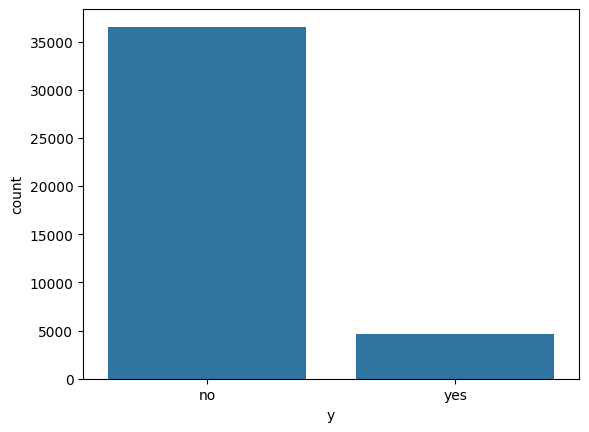

In [6]:
# Target distribution
sns.countplot(x='y',data=df)
plt.show()


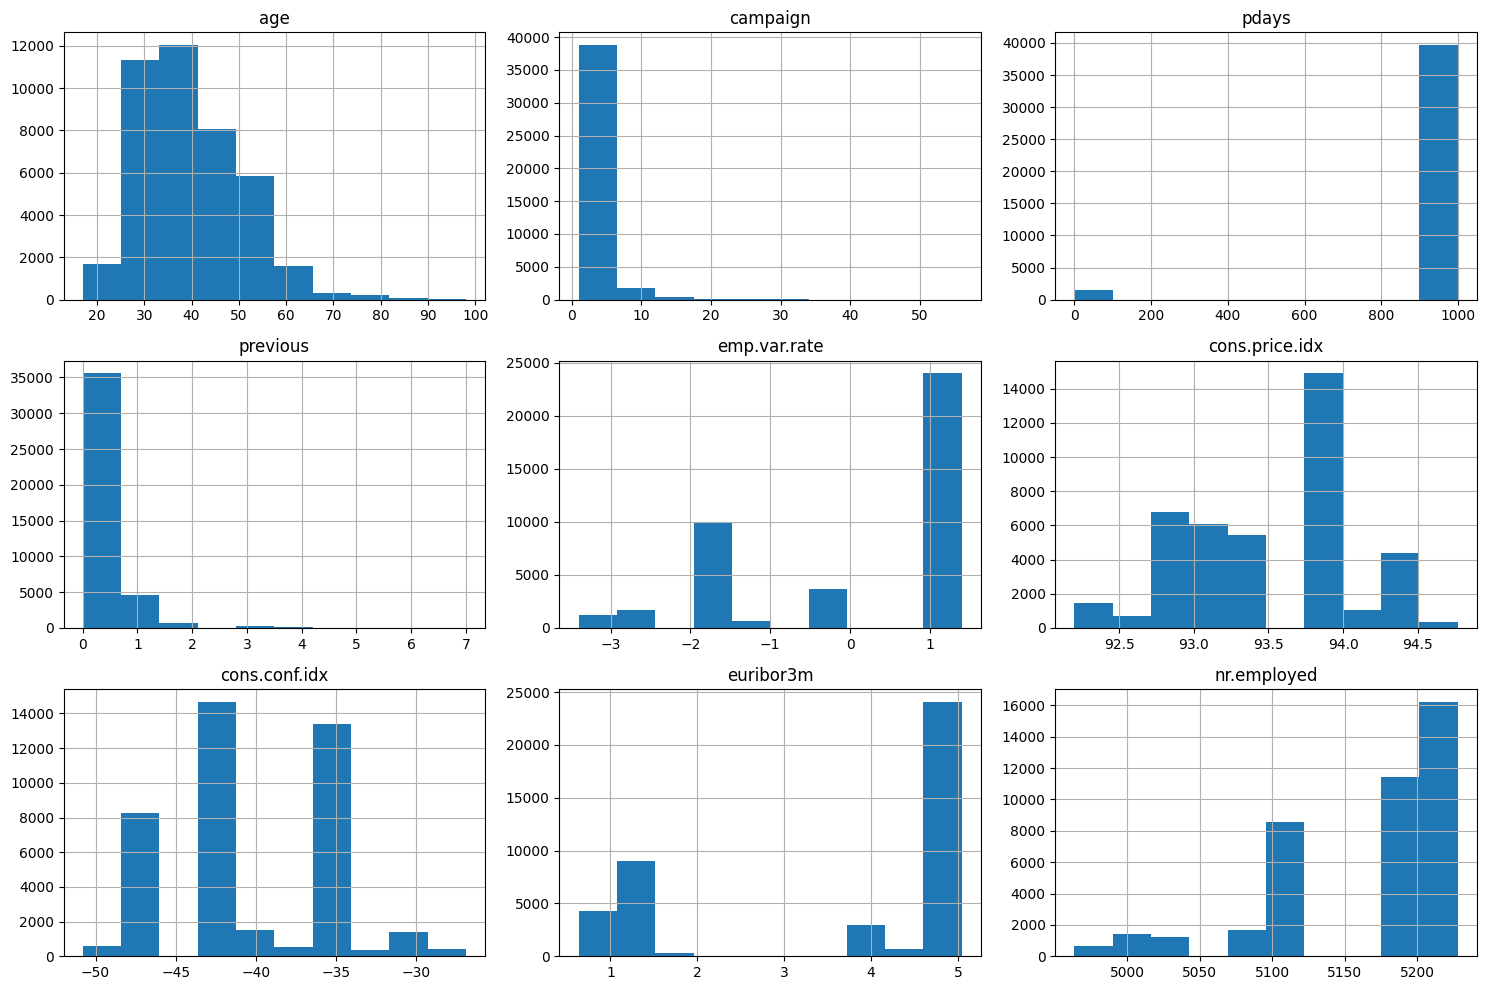

In [7]:
# Numerical distributions
num=df.select_dtypes(include=np.number).columns
df[num].hist(figsize=(15,10))
plt.tight_layout()
plt.show()


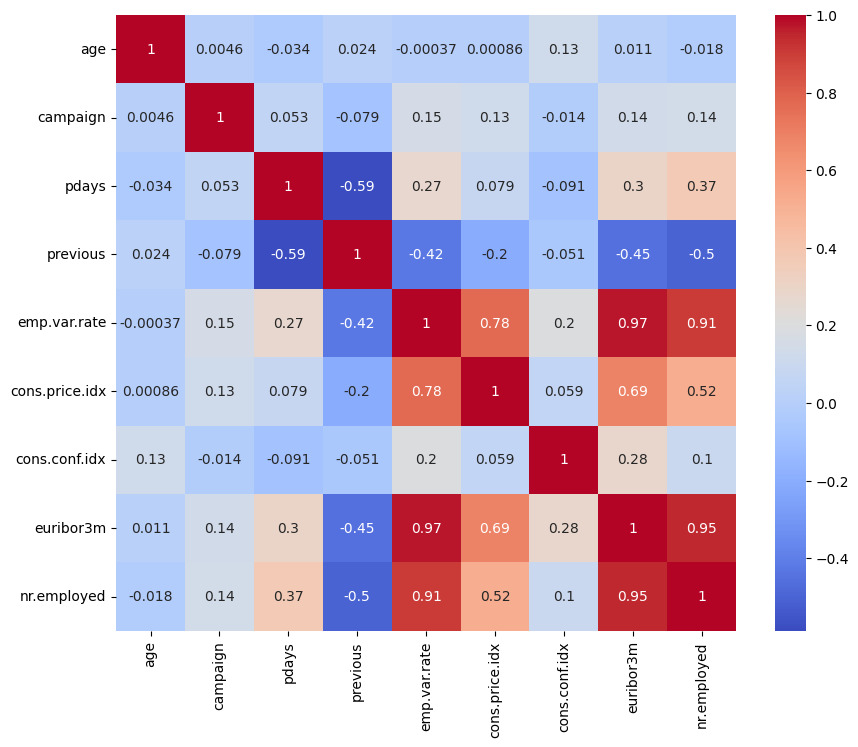

In [8]:
# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df[num].corr(),annot=True,cmap='coolwarm')
plt.show()


In [9]:
# Encode categorical columns
le=LabelEncoder()
for c in df.columns:
    if df[c].dtype=='object':
        df[c]=le.fit_transform(df[c].astype(str))


In [10]:
# Feature/target split
X=df.drop('y',axis=1)
y=df['y']

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y)

scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)


In [11]:
models={
'Logistic Regression':LogisticRegression(max_iter=1000),
'Decision Tree':DecisionTreeClassifier(random_state=42),
'Random Forest':RandomForestClassifier(random_state=42),
'Gradient Boosting':GradientBoostingClassifier(random_state=42)
}

results=[]

for name,model in models.items():
    model.fit(X_train,y_train)
    pred=model.predict(X_test)

    print("\n",name)
    print(confusion_matrix(y_test,pred))
    print(classification_report(y_test,pred))

    results.append({
        'Model':name,
        'Accuracy':accuracy_score(y_test,pred),
        'Precision':precision_score(y_test,pred),
        'Recall':recall_score(y_test,pred),
        'F1 Score':f1_score(y_test,pred)
    })

results_df=pd.DataFrame(results)
results_df.sort_values('Accuracy',ascending=False)



 Logistic Regression
[[7229   81]
 [ 737  191]]
              precision    recall  f1-score   support

           0       0.91      0.99      0.95      7310
           1       0.70      0.21      0.32       928

    accuracy                           0.90      8238
   macro avg       0.80      0.60      0.63      8238
weighted avg       0.88      0.90      0.88      8238


 Decision Tree
[[6643  667]
 [ 611  317]]
              precision    recall  f1-score   support

           0       0.92      0.91      0.91      7310
           1       0.32      0.34      0.33       928

    accuracy                           0.84      8238
   macro avg       0.62      0.63      0.62      8238
weighted avg       0.85      0.84      0.85      8238


 Random Forest
[[7110  200]
 [ 643  285]]
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      7310
           1       0.59      0.31      0.40       928

    accuracy                           0.90    

,Model,Accuracy,Precision,Recall,F1 Score
3,Gradient Boosting,0.902161,0.695513,0.233836,0.350000
0,Logistic Regression,0.900704,0.702206,0.205819,0.318333
2,Random Forest,0.897669,0.587629,0.307112,0.403397
1,Decision Tree,0.844865,0.322154,0.341595,0.331590


In [12]:
# GridSearchCV - Decision Tree
params={'max_depth':[3,5,10,None],
'min_samples_split':[2,5,10]}

grid_dt=GridSearchCV(DecisionTreeClassifier(random_state=42),
params,cv=5,scoring='accuracy')
grid_dt.fit(X_train,y_train)

print(grid_dt.best_params_)
print(grid_dt.best_score_)


{'max_depth': 5, 'min_samples_split': 10}
0.8996965098634293


In [13]:
# GridSearchCV - Random Forest
params={
'n_estimators':[100,200],
'max_depth':[None,10,20],
'min_samples_split':[2,5]
}

grid_rf=GridSearchCV(RandomForestClassifier(random_state=42),
params,cv=5,scoring='accuracy')
grid_rf.fit(X_train,y_train)

print(grid_rf.best_params_)
print(grid_rf.best_score_)


{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
0.8993323216995448


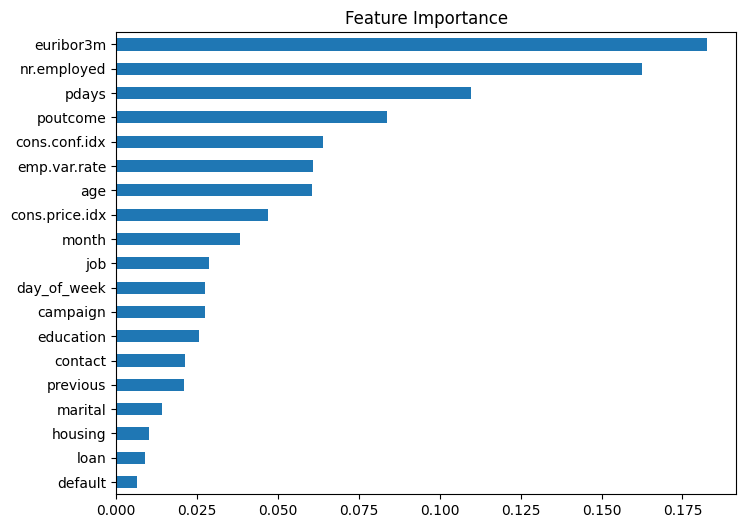

In [14]:
# Feature Importance
rf=grid_rf.best_estimator_
importance=pd.Series(rf.feature_importances_,index=X.columns)
importance.sort_values().plot(kind='barh',figsize=(8,6))
plt.title('Feature Importance')
plt.show()


## Conclusion
Comparing model performance using the results table and summarizing the best-performing classifier for predicting whether a customer subscribes to a term deposit.